In [1]:
# 1. Environment Setup: Upgrade core libraries to resolve version conflicts
!pip install --upgrade transformers accelerate -q

In [2]:
# 2. Imports
# Standard Libraries
import os
import shutil
from pathlib import Path

# Data Processing
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# Machine Learning & NLP
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel
from google.colab import drive


**Step 1: Environment Setup & Data Loading** <br><br>
Plan:
We will mount your Google Drive, install the necessary libraries, and load the data_clinpred_emb_transform.csv file. We will also ensure all text columns are explicitly cast to strings to prevent the tokenizer from crashing on empty values.
Code:

In [3]:
# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Paths
PROJECT_PATH = '/content/drive/MyDrive/clintrialpredict'
csv_path = os.path.join(PROJECT_PATH, 'data_clinpred_emb_transform.csv')

# 3. Load Data
df = pd.read_csv(csv_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# 4. Ensure all text columns are strings
text_columns = ['txt_scientific_essence', 'txt_criteria', 'txt_primary_endpoints']
for col in text_columns:
    df[col] = df[col].astype(str)

print(f"Data Loaded: {len(df)} rows.")
print(f"Columns: {df.columns.tolist()}")

Data Loaded: 34155 rows.
Columns: ['nct_id', 'target', 'txt_scientific_essence', 'txt_criteria', 'txt_primary_endpoints']


**Step 2: Model Initialization** <br><br>
Plan:
We will load the BioBERT model and move it to the GPU. I am using the robust loading settings we established to avoid the .safetensors download hang.
Code:

In [5]:

# 2. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 3. Initialize BioBERT
MODEL_NAME = "dmis-lab/biobert-v1.1"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Using the robust settings from your previous successful run
model = AutoModel.from_pretrained(
    MODEL_NAME,
    use_safetensors=True,
    low_cpu_mem_usage=True
).to(device)

model.eval()
print("BioBERT Model Loaded Successfully.")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

BioBERT Model Loaded Successfully.


**Step 3: Multi-Pillar Extraction Loop** <br><br>
Plan:
We will define the extraction function and run it in a loop for your three pillars. This will generate three separate 768-dimensional matrices. We use Mean Pooling to condense the text into a single vector.
Code:

In [6]:
# 1. Dataset Class
class ClinicalDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return self.texts[idx]

# 2. Extraction Function
def get_embeddings(dataloader):
    all_embeddings = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Processing Batches"):
            inputs = tokenizer(batch, padding=True, truncation=True,
                               max_length=512, return_tensors="pt").to(device)
            outputs = model(**inputs)

            # Mean Pooling logic
            mask = inputs['attention_mask'].unsqueeze(-1).expand(outputs.last_hidden_state.size()).float()
            mean_emb = torch.sum(outputs.last_hidden_state * mask, 1) / torch.clamp(mask.sum(1), min=1e-9)
            all_embeddings.append(mean_emb.cpu().numpy())
    return np.vstack(all_embeddings)

# 3. Execution Loop for the 3 Pillars
# Mapping: Column Name -> File Prefix
pillars = {
    'txt_criteria': 'crit',
    'txt_scientific_essence': 'sci',
    'txt_primary_endpoints': 'endp'
}

for col, prefix in pillars.items():
    print(f"\n>>> Starting Extraction for Pillar: {col} (Prefix: {prefix}_)")

    dataset = ClinicalDataset(df[col].tolist())
    loader = DataLoader(dataset, batch_size=32)

    # Generate Embeddings
    embeddings = get_embeddings(loader)

    # Save locally and copy to Drive
    local_file = f'biobert_{prefix}_raw.npy'
    drive_file = os.path.join(PROJECT_PATH, local_file)

    np.save(local_file, embeddings)
    shutil.copy(local_file, drive_file)

    print(f"Finished {col}. Saved to: {drive_file}")
    print(f"Matrix Shape: {embeddings.shape}")

print("\n[ALL EXTRACTIONS COMPLETE]")


>>> Starting Extraction for Pillar: txt_criteria (Prefix: crit_)


Processing Batches:   0%|          | 0/1068 [00:00<?, ?it/s]

Finished txt_criteria. Saved to: /content/drive/MyDrive/clintrialpredict/biobert_crit_raw.npy
Matrix Shape: (34155, 768)

>>> Starting Extraction for Pillar: txt_scientific_essence (Prefix: sci_)


Processing Batches:   0%|          | 0/1068 [00:00<?, ?it/s]

Finished txt_scientific_essence. Saved to: /content/drive/MyDrive/clintrialpredict/biobert_sci_raw.npy
Matrix Shape: (34155, 768)

>>> Starting Extraction for Pillar: txt_primary_endpoints (Prefix: endp_)


Processing Batches:   0%|          | 0/1068 [00:00<?, ?it/s]

Finished txt_primary_endpoints. Saved to: /content/drive/MyDrive/clintrialpredict/biobert_endp_raw.npy
Matrix Shape: (34155, 768)

[ALL EXTRACTIONS COMPLETE]


**PCA Diagnostic for Multi-Pillar Optimization**


>>> Analyzing Pillar: CRIT


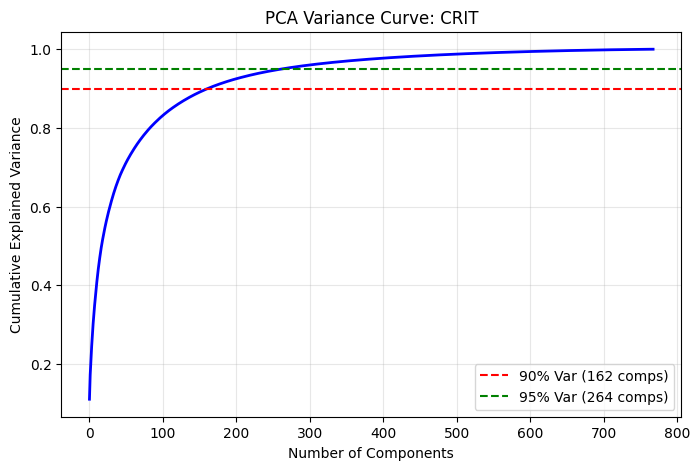

Results for crit:
  - 90% Variance: 162 components
  - 95% Variance: 264 components

>>> Analyzing Pillar: SCI


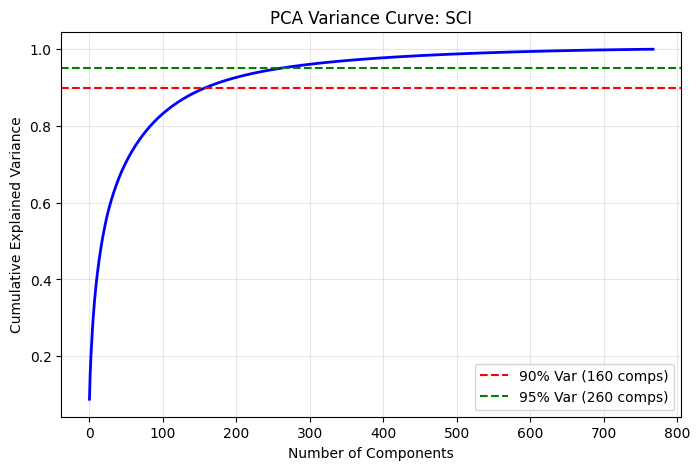

Results for sci:
  - 90% Variance: 160 components
  - 95% Variance: 260 components

>>> Analyzing Pillar: ENDP


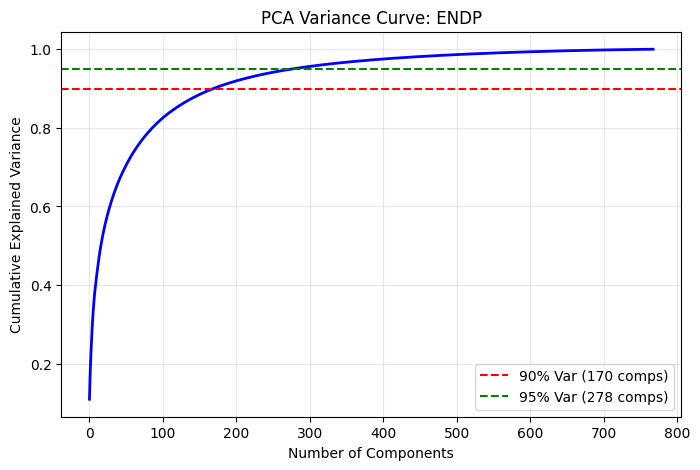

Results for endp:
  - 90% Variance: 170 components
  - 95% Variance: 278 components


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

def analyze_pca_variance(prefix, project_path):
    """
    Loads raw embeddings, scales them, and plots the variance curve.
    """
    file_path = os.path.join(project_path, f'biobert_{prefix}_raw.npy')
    print(f"\n>>> Analyzing Pillar: {prefix.upper()}")

    if not os.path.exists(file_path):
        print(f"Error: {file_path} not found.")
        return None

    # 1. Load and Scale
    X = np.load(file_path)
    X_scaled = StandardScaler().fit_transform(X)

    # 2. Fit full PCA
    pca = PCA(random_state=42)
    pca.fit(X_scaled)

    # 3. Calculate Cumulative Variance
    cum_var = np.cumsum(pca.explained_variance_ratio_)

    # 4. Find Thresholds
    n_90 = np.argmax(cum_var >= 0.90) + 1
    n_95 = np.argmax(cum_var >= 0.95) + 1

    # 5. Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(cum_var, linewidth=2, color='blue')
    plt.axhline(y=0.90, color='red', linestyle='--', label=f'90% Var ({n_90} comps)')
    plt.axhline(y=0.95, color='green', linestyle='--', label=f'95% Var ({n_95} comps)')
    plt.title(f'PCA Variance Curve: {prefix.upper()}')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(f"Results for {prefix}:")
    print(f"  - 90% Variance: {n_90} components")
    print(f"  - 95% Variance: {n_95} components")

    return n_90, n_95

# --- EXECUTION ---
results = {}
for p_prefix in ['crit', 'sci', 'endp']:
    n90, n95 = analyze_pca_variance(p_prefix, PROJECT_PATH)
    results[p_prefix] = {'n90': n90, 'n95': n95}